# White-Black Within-Inflation Trend Tests

**Hypothesis:** Half Edge with positive λ includes same-tract (within) products alongside cross-tract ones. These within products are mechanically inflated by variance in tract-level Black counts. As Black-count heterogeneity fell from 1980 to 2020 — tracts becoming more similar in composition — the within term shrank, pulling Half Edge(λ=1) down while Moran (which normalises by variance) stayed flatter.

**Four tests:**

1. **Algebra** — Does the math support the mechanism? We derive that `within_xx_inflation = 1 + CV(Black)²`, linking the within term directly to Black-count spread across tracts.
2. **CV trend** — Does Black-count CV fall over time?
3. **Within share** — Does the within component's share of total product mass fall?
4. **Lambda ratio** — Does HalfEdge(λ=1) / HalfEdge(λ=0) converge toward 1?

In [16]:
from pathlib import Path
import json
import re

from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.options.display.float_format = "{:.4f}".format

project_root = Path.cwd().resolve()
while project_root != project_root.parent and not (project_root / "outputs").exists():
    project_root = project_root.parent

csv_path = project_root / "outputs/tracts_in_cbsa/white_black.csv"
if not csv_path.exists():
    raise FileNotFoundError(csv_path)

csv_path

PosixPath('/Users/maria/Documents/capy-bara/outputs/tracts_in_cbsa/white_black.csv')

In [17]:
metrics = pd.read_csv(csv_path)

required_columns = [
    "filename",
    "x_col",
    "y_col",
    "half_edge_exact_0",
    "half_edge_exact_1",
    "moran_P",
    "total_nodes",
    "total_edges",
]

metrics["year"] = metrics["filename"].str.extract(r"/(\d{4})/")[0].astype(int)
metrics["cbsa"] = metrics["filename"].str.extract(r"cbsa_(\d+)_")[0]
metrics["area_key"] = metrics["year"].astype(str) + "_" + metrics["cbsa"].astype(str)
metrics["graph_path"] = metrics["filename"].map(lambda filename: project_root / filename)

missing_graphs = metrics.loc[~metrics["graph_path"].map(Path.exists), "graph_path"].tolist()
if missing_graphs:
    raise FileNotFoundError(f"Missing graph JSONs, starting with: {missing_graphs[:5]}")

year_order = sorted(metrics["year"].unique())
metrics["year_label"] = pd.Categorical(
    metrics["year"].astype(str),
    categories=[str(year) for year in year_order],
    ordered=True,
)

print(f"Loaded {len(metrics):,} White-Black metric rows")
display(metrics.groupby("year").size().rename("n_areas").to_frame())

Loaded 1,939 White-Black metric rows


,n_areas
year,
1980,379
1990,384
2000,392
2010,392
2020,392


## Test 1: Algebra

**The within-inflation identity**

Half Edge's numerator (for the X-X product, i.e. Black counts only) splits cleanly into within-tract and cross-tract sums:

```
Σ_i  x_i · x_i ← within-tract: same-tract self-product (diagonal)
Σ_{edges} x_i · x_j ← between-tract: cross-tract product
```

With λ=0 only the between term counts; with λ=1 both count.

**Why the within term inflates with heterogeneity**

Hold the mean Black count per tract fixed at *m* and vary the spread. For three pools of two tracts with mean = 5 (total = 10):

| Pool | mean(x²) = m² + Var | avg cross-product ≈ m² |
|------|---------------------|------------------------|
| {5, 5} even | (25 + 25)/2 = **25** | 25 |
| {9, 1} uneven | (81 + 1)/2 = **41** | 25 |
| {10, 0} extreme | (100 + 0)/2 = **50** | 25 |

The diagonal term climbs as you spread counts out; the edge term stays flat. This is because a cross-tract product x_i · x_j between two randomly-arranged tracts has expected value m · m = m², regardless of variance — the two factors are independent draws from the same pool, so variance cancels. You can verify on the extreme pool: the four ordered neighbour pairs give products 100, 0, 0, 0 → average 25.

This generalises exactly to:

```
within_xx per node  =  m²  +  Var(x)        ← grows with heterogeneity
between_xx per edge ≈  m²                    ← flat at the random-arrangement expectation
```

**The normalised inflation factor — why we work with means**

Half Edge sums raw products, so `within_xx = Σ x_i²` scales with both n and mean counts. To isolate the *shape* of the distribution (comparable across metros of different sizes and different Black populations), we normalise by n and by mean(x)²:

```
within_xx_inflation  =  (Σ x_i² / n) / mean(x)²
                      =  mean(x²) / mean(x)²
                      =  1 + CV(x)²
```

- **1** is the equal-count baseline (all tracts identical → CV = 0 → no inflation)
- The excess above 1 is exactly the squared CV — pure shape, no scale.

This is a diagnostic we construct to understand the within term's magnitude. The HalfEdge formula itself does not normalise this way.

**Why Moran is not sensitive to this**

Moran's I centres and normalises by variance: `Σ z_i · z_j`, where `z_i = (x_i − mean) / sd`. The within term doesn't appear (diagonal entries are zero in the spatial-weights matrix), and the normalisation by sd² cancels the scale of the between term. So a change in Black-count heterogeneity shifts Half Edge(λ=1) but not Moran.

**Prediction:** If CV(Black) falls over 1980–2020, `within_xx_inflation` and the within share both fall, and HalfEdge(λ=1) / HalfEdge(λ=0) converges toward 1.

In [18]:
decomposition_records = []

for row_number, row in enumerate(metrics.itertuples(index=False), start=1):
    with row.graph_path.open() as graph_file:
        graph_data = json.load(graph_file)

    nodes = graph_data["nodes"]
    adjacency = graph_data["adjacency"]

    black_counts = np.array([float(node.get("BLACK", 0) or 0) for node in nodes], dtype=float)
    white_counts = np.array([float(node.get("WHITE", 0) or 0) for node in nodes], dtype=float)
    total_counts = black_counts + white_counts

    black_count_mean = black_counts.mean()
    black_count_var = black_counts.var(ddof=0)
    black_count_cv = (
        black_counts.std(ddof=0) / black_count_mean if black_count_mean > 0 else np.nan
    )
    total_pop_mean = total_counts.mean()
    total_pop_cv = (
        total_counts.std(ddof=0) / total_pop_mean if total_pop_mean > 0 else np.nan
    )

    within_xx = float(np.dot(black_counts, black_counts))
    within_xy = float(np.dot(black_counts, white_counts))
    within_yy = float(np.dot(white_counts, white_counts))

    id_to_idx = {node["id"]: i for i, node in enumerate(nodes)}
    src_idxs, tgt_idxs = [], []
    for src_idx, (node, neighbors) in enumerate(zip(nodes, adjacency)):
        for neighbor in neighbors:
            tgt_idx = id_to_idx[neighbor["id"]]
            if src_idx < tgt_idx:
                src_idxs.append(src_idx)
                tgt_idxs.append(tgt_idx)

    if src_idxs:
        s = np.array(src_idxs)
        t = np.array(tgt_idxs)
        between_xx = float(2 * np.dot(black_counts[s], black_counts[t]))
        between_xy = float(np.sum(black_counts[s] * white_counts[t] + black_counts[t] * white_counts[s]))
        between_yy = float(2 * np.dot(white_counts[s], white_counts[t]))
    else:
        between_xx = between_xy = between_yy = 0.0

    n_nodes = len(nodes)
    n_edges = len(src_idxs)
    within_total = within_xx + (2 * within_xy) + within_yy
    between_total = between_xx + (2 * between_xy) + between_yy
    within_xx_per_node = within_xx / n_nodes if n_nodes else np.nan
    within_xx_inflation = (
        within_xx_per_node / (black_count_mean**2) if black_count_mean > 0 else np.nan
    )

    decomposition_records.append(
        {
            "filename": row.filename,
            "area_key": row.area_key,
            "year": row.year,
            "cbsa": row.cbsa,
            "edge_count_from_json": n_edges,
            "black_count_mean": black_count_mean,
            "black_count_var": black_count_var,
            "black_count_cv": black_count_cv,
            "total_pop_cv": total_pop_cv,
            "within_xx": within_xx,
            "within_xy": within_xy,
            "within_yy": within_yy,
            "between_xx": between_xx,
            "between_xy": between_xy,
            "between_yy": between_yy,
            "within_total": within_total,
            "between_total": between_total,
            "within_total_share": within_total / (within_total + between_total),
            "within_xx_share": within_xx / (within_xx + between_xx),
            "within_xx_per_node": within_xx_per_node,
            "within_xx_inflation": within_xx_inflation,
            "within_xx_inflation_identity": 1 + black_count_cv**2,
        }
    )

    if row_number % 500 == 0:
        print(f"Loaded {row_number:,} graph JSONs...")

decomposition = pd.DataFrame(decomposition_records)
print(f"Computed decomposition diagnostics for {len(decomposition):,} graphs")

Loaded 500 graph JSONs...
Loaded 1,000 graph JSONs...
Loaded 1,500 graph JSONs...
Computed decomposition diagnostics for 1,939 graphs


In [19]:
analysis = metrics.merge(
    decomposition,
    on=["filename", "area_key", "year", "cbsa"],
    how="inner",
    validate="one_to_one",
)

if len(analysis) != len(metrics):
    raise ValueError(f"Expected {len(metrics)} merged rows, got {len(analysis)}")

edge_mismatch = analysis["edge_count_from_json"] - analysis["total_edges"]
if not (edge_mismatch == 0).all():
    raise ValueError(edge_mismatch.describe())

identity_error = (
    analysis["within_xx_inflation"] - analysis["within_xx_inflation_identity"]
).abs().max()
if identity_error > 1e-8:
    raise ValueError(f"within_xx inflation identity failed: max error {identity_error}")

analysis["he_lambda_gap"] = (
    analysis["half_edge_exact_1"] - analysis["half_edge_exact_0"]
)
analysis["he_lambda_ratio"] = (
    analysis["half_edge_exact_1"] / analysis["half_edge_exact_0"]
)
analysis["he_lambda_pct_change"] = analysis["he_lambda_ratio"] - 1

print(f"Max identity error: {identity_error:.3e}")
display(
    analysis[
        [
            "year",
            "cbsa",
            "half_edge_exact_0",
            "half_edge_exact_1",
            "moran_P",
            "black_count_cv",
            "within_total_share",
            "within_xx_inflation",
            "he_lambda_gap",
            "he_lambda_ratio",
        ]
    ].head()
)

Max identity error: 7.105e-15


,year,cbsa,half_edge_exact_0,half_edge_exact_1,moran_P,black_count_cv,within_total_share,within_xx_inflation,he_lambda_gap,he_lambda_ratio
0,2020,14540,0.5293,0.5339,0.2138,1.2225,0.1797,2.4945,0.0046,1.0086
1,2020,26380,0.5289,0.5383,0.3258,0.9159,0.1682,1.8389,0.0095,1.0179
2,2020,22520,0.5215,0.5278,0.2399,0.8596,0.1780,1.7389,0.0062,1.0120
3,2020,23900,0.5027,0.5034,0.5286,0.9455,0.1892,1.8940,0.0007,1.0014
4,2020,42700,0.5141,0.5240,0.1980,0.9812,0.1909,1.9628,0.0099,1.0192


## Baseline: Metric Trends Over Time

Yearly means for edge-only Half Edge, default Half Edge, and Moran. The divergence between Half Edge(λ=1) and Moran after 1980 is what we are trying to explain.

,year,"Half Edge, lambda=0","Half Edge, lambda=1",Moran
0,1980,0.5518,0.5639,0.2825
1,1990,0.5494,0.5582,0.3764
2,2000,0.5477,0.5555,0.4028
3,2010,0.5457,0.5525,0.4330
4,2020,0.5460,0.5523,0.4690


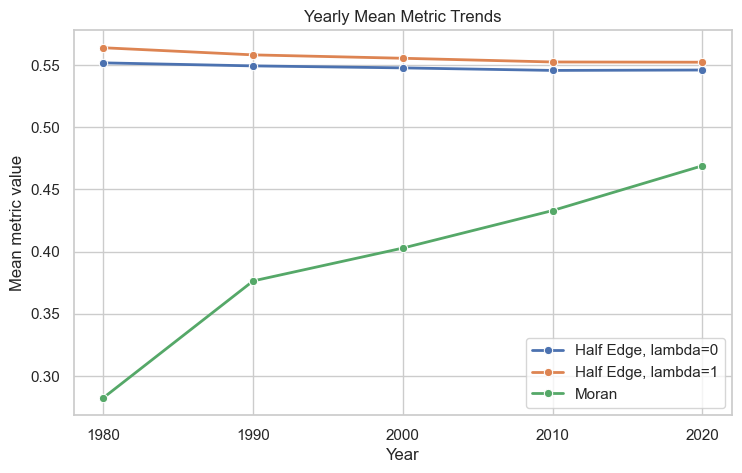

In [20]:
metric_labels = {
    "half_edge_exact_0": "Half Edge, lambda=0",
    "half_edge_exact_1": "Half Edge, lambda=1",
    "moran_P": "Moran",
}

yearly_metric_means = (
    analysis.groupby("year", as_index=False)[list(metric_labels)]
    .mean()
)
metric_plot_data = yearly_metric_means.melt(
    id_vars="year",
    var_name="metric",
    value_name="mean_value",
)
metric_plot_data["metric"] = metric_plot_data["metric"].map(metric_labels)

display(yearly_metric_means.rename(columns=metric_labels))

fig, ax = plt.subplots(figsize=(8.5, 5))
sns.lineplot(
    data=metric_plot_data,
    x="year",
    y="mean_value",
    hue="metric",
    marker="o",
    linewidth=2,
    ax=ax,
)
ax.set_title("Yearly Mean Metric Trends")
ax.set_xlabel("Year")
ax.set_ylabel("Mean metric value")
ax.set_xticks(year_order)
ax.legend(title=None)
plt.show()

## Test 2: Does Black-Count CV Fall Over Time?

From the identity `within_xx_inflation = 1 + CV(Black)²`, the within term tracks the coefficient of variation of Black counts across tracts. If CV falls, the within term falls with it. The table below confirms both move together.

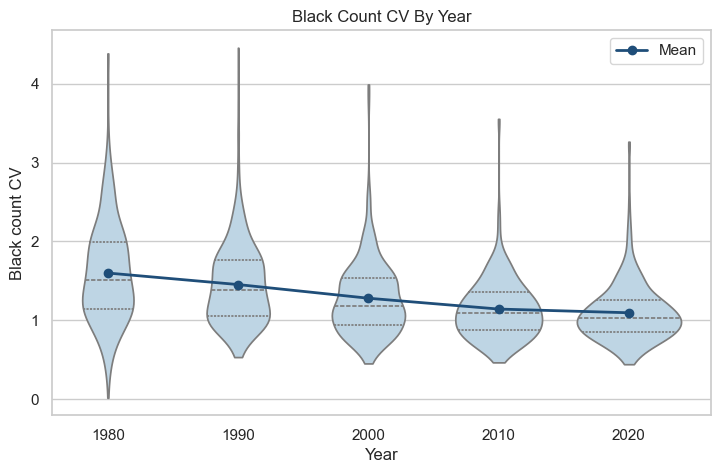

,mean_black_count_cv,mean_within_xx_inflation
year,,
1980,1.5982,3.5543
1990,1.4518,3.1078
2000,1.2784,2.6342
2010,1.1410,2.3019
2020,1.0940,2.1968


In [21]:
black_cv_means = analysis.groupby("year")["black_count_cv"].mean().reindex(year_order)

fig, ax = plt.subplots(figsize=(8.5, 5))
sns.violinplot(
    data=analysis,
    x="year_label",
    y="black_count_cv",
    inner="quartile",
    cut=0,
    color="#B8D7EA",
    ax=ax,
)
ax.plot(
    range(len(year_order)),
    black_cv_means.values,
    marker="o",
    color="#1F4E79",
    linewidth=2,
    label="Mean",
)
ax.set_title("Black Count CV By Year")
ax.set_xlabel("Year")
ax.set_ylabel("Black count CV")
ax.legend()
plt.show()

cv_summary = black_cv_means.rename("mean_black_count_cv").to_frame()
cv_summary["mean_within_xx_inflation"] = 1 + cv_summary["mean_black_count_cv"] ** 2
display(cv_summary)

## Test 3: Does the Within Component Share Fall?

`within_total_share` is the fraction of all product mass accounted for by same-tract pairs:

`within_total_share = within_total / (within_total + between_total)`

where `within_total = within_xx + 2·within_xy + within_yy` and `between_total` is the same sum across adjacent-tract pairs.

If the algebra holds, this share should fall as CV falls — the between term stays flat while the within term shrinks.

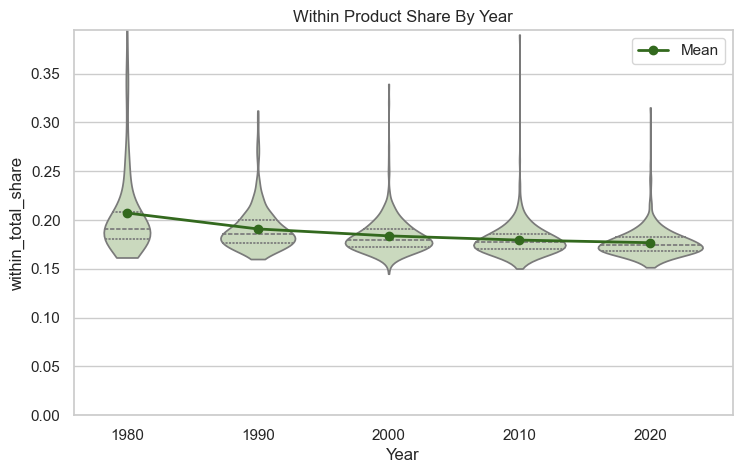

,mean_within_total_share
year,
1980,0.2072
1990,0.1908
2000,0.1837
2010,0.1794
2020,0.1767


In [22]:
within_share_means = analysis.groupby("year")["within_total_share"].mean().reindex(year_order)

fig, ax = plt.subplots(figsize=(8.5, 5))
sns.violinplot(
    data=analysis,
    x="year_label",
    y="within_total_share",
    inner="quartile",
    cut=0,
    color="#C9DDBA",
    ax=ax,
)
ax.plot(
    range(len(year_order)),
    within_share_means.values,
    marker="o",
    color="#33691E",
    linewidth=2,
    label="Mean",
)
ax.set_title("Within Product Share By Year")
ax.set_xlabel("Year")
ax.set_ylabel("within_total_share")
ax.set_ylim(0, min(1, analysis["within_total_share"].quantile(0.995) * 1.1))
ax.legend()
plt.show()

display(within_share_means.rename("mean_within_total_share").to_frame())

## Test 4: Does the Lambda Ratio Converge Toward 1?

If the within component shrinks, Half Edge(λ=1) should approach Half Edge(λ=0) over time. The ratio:

`he_lambda_ratio = HalfEdge(λ=1) / HalfEdge(λ=0)`

starts above 1 (when within products inflate the numerator) and should fall toward 1 as the within contribution diminishes.

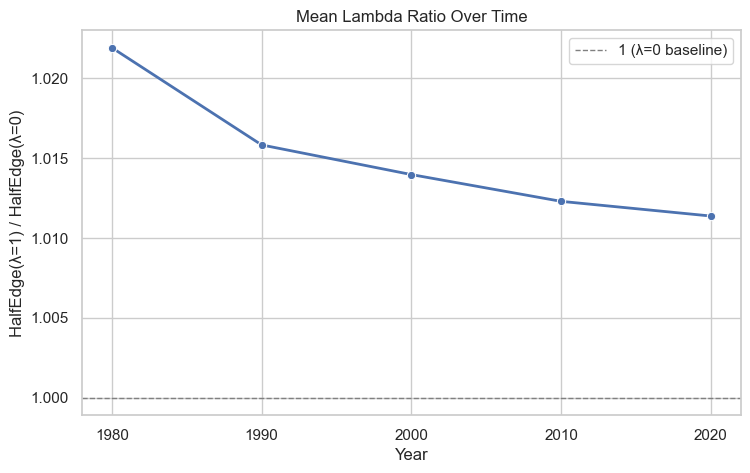

,component,1980,2020,change
0,HalfEdge(λ=1),0.5639,0.5523,-0.0116
1,HalfEdge(λ=0),0.5518,0.5460,-0.0058
2,Lambda ratio,1.0219,1.0114,-0.0105


In [23]:
yearly_lambda = (
    analysis.groupby("year", as_index=False)
    .agg(
        half_edge_lam_0=("half_edge_exact_0", "mean"),
        half_edge_lam_1=("half_edge_exact_1", "mean"),
        moran=("moran_P", "mean"),
        he_lambda_gap=("he_lambda_gap", "mean"),
        he_lambda_ratio=("he_lambda_ratio", "mean"),
        black_count_cv=("black_count_cv", "mean"),
        within_total_share=("within_total_share", "mean"),
        within_xx_inflation=("within_xx_inflation", "mean"),
    )
)

fig, ax = plt.subplots(figsize=(8.5, 5))
sns.lineplot(
    data=yearly_lambda,
    x="year",
    y="he_lambda_ratio",
    marker="o",
    linewidth=2,
    ax=ax,
)
ax.axhline(1, color="0.5", linewidth=1, linestyle="--", label="1 (λ=0 baseline)")
ax.set_title("Mean Lambda Ratio Over Time")
ax.set_xlabel("Year")
ax.set_ylabel("HalfEdge(λ=1) / HalfEdge(λ=0)")
ax.set_xticks(year_order)
ax.legend()
plt.show()

first_year = min(year_order)
last_year = max(year_order)
first = yearly_lambda.loc[yearly_lambda["year"] == first_year].iloc[0]
last = yearly_lambda.loc[yearly_lambda["year"] == last_year].iloc[0]

display(pd.DataFrame({
    "component": ["HalfEdge(λ=1)", "HalfEdge(λ=0)", "Lambda ratio"],
    str(first_year): [first["half_edge_lam_1"], first["half_edge_lam_0"], first["he_lambda_ratio"]],
    str(last_year): [last["half_edge_lam_1"], last["half_edge_lam_0"], last["he_lambda_ratio"]],
    "change": [
        last["half_edge_lam_1"] - first["half_edge_lam_1"],
        last["half_edge_lam_0"] - first["half_edge_lam_0"],
        last["he_lambda_ratio"] - first["he_lambda_ratio"],
    ],
}))

## Summary: Do the Pieces Move Together?

All four quantities predicted to fall — Black-count CV, within share, `within_xx_inflation`, and the lambda ratio — should trend in the same direction while Moran moves opposite. The yearly means are z-scored so variables with different units can be compared on one axis. A z-score of 0 means that year is at the quantity's 1980–2020 average; ±1 is one standard deviation from it.

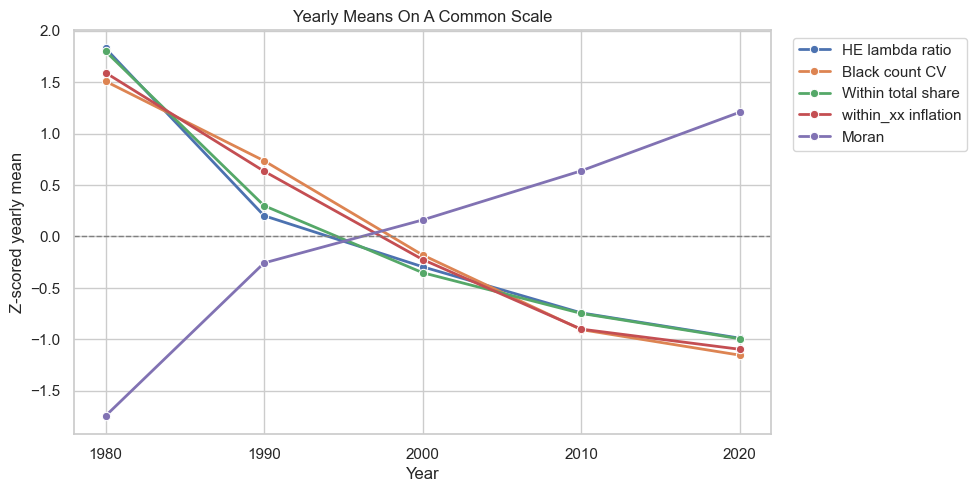

,quantity,mean_1980,mean_2020,change,pct_change_from_first_year
0,HE lambda ratio,1.0219,1.0114,-0.0105,-0.0103
1,Black count CV,1.5982,1.0940,-0.5042,-0.3155
2,Within total share,0.2072,0.1767,-0.0304,-0.1469
3,within_xx inflation,3.9548,2.3303,-1.6245,-0.4108
4,Moran,0.2825,0.4690,0.1865,0.6603


,he_lambda_ratio,black_count_cv,within_total_share,within_xx_inflation,moran
he_lambda_ratio,1.0000,0.9550,0.9990,0.9720,-0.9910
black_count_cv,0.9550,1.0000,0.9650,0.9980,-0.9640
within_total_share,0.9990,0.9650,1.0000,0.9790,-0.9900
within_xx_inflation,0.9720,0.9980,0.9790,1.0000,-0.9750
moran,-0.9910,-0.9640,-0.9900,-0.9750,1.0000


In [24]:
comparison_columns = {
    "he_lambda_ratio": "HE lambda ratio",
    "black_count_cv": "Black count CV",
    "within_total_share": "Within total share",
    "within_xx_inflation": "within_xx inflation",
    "moran": "Moran",
}

zscore_data = yearly_lambda[["year", *comparison_columns]].copy()
for column in comparison_columns:
    sd = zscore_data[column].std(ddof=0)
    zscore_data[column] = (zscore_data[column] - zscore_data[column].mean()) / sd

zscore_plot_data = zscore_data.melt(
    id_vars="year",
    var_name="quantity",
    value_name="z_scored_yearly_mean",
)
zscore_plot_data["quantity"] = zscore_plot_data["quantity"].map(comparison_columns)

fig, ax = plt.subplots(figsize=(9, 5.25))
sns.lineplot(
    data=zscore_plot_data,
    x="year",
    y="z_scored_yearly_mean",
    hue="quantity",
    marker="o",
    linewidth=2,
    ax=ax,
)
ax.axhline(0, color="0.5", linewidth=1, linestyle="--")
ax.set_title("Yearly Means On A Common Scale")
ax.set_xlabel("Year")
ax.set_ylabel("Z-scored yearly mean")
ax.set_xticks(year_order)
ax.legend(title=None, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

cols = list(comparison_columns)
start_vals = np.array([first[c] for c in cols])
end_vals = np.array([last[c] for c in cols])
trend_check = pd.DataFrame({
    "quantity": list(comparison_columns.values()),
    f"mean_{first_year}": start_vals,
    f"mean_{last_year}": end_vals,
    "change": end_vals - start_vals,
    "pct_change_from_first_year": np.where(
        start_vals != 0, (end_vals - start_vals) / start_vals, np.nan
    ),
})
display(trend_check)

display(
    yearly_lambda[
        ["he_lambda_ratio", "black_count_cv", "within_total_share", "within_xx_inflation", "moran"]
    ].corr().round(3)
)

## Sensitivity Check: Common CBSAs Only

The full-panel means above use all available CBSAs in each year. CBSAs enter and leave as definitions change, so the composition of the sample shifts. This check repeats the same means using only CBSAs present in all five years, so the trend cannot be driven by areas entering or leaving the file.

In [25]:
common_cbsas = (
    analysis.groupby("cbsa")["year"]
    .nunique()
    .loc[lambda counts: counts == len(year_order)]
    .index
)
common_analysis = analysis[analysis["cbsa"].isin(common_cbsas)].copy()

selected_trend_columns = [
    "half_edge_exact_0",
    "half_edge_exact_1",
    "moran_P",
    "he_lambda_gap",
    "black_count_cv",
    "within_total_share",
    "within_xx_inflation",
]

full_panel_summary = (
    analysis.groupby("year")[selected_trend_columns]
    .mean()
    .assign(panel="all available CBSAs")
    .reset_index()
)
common_panel_summary = (
    common_analysis.groupby("year")[selected_trend_columns]
    .mean()
    .assign(panel=f"common CBSAs only (n={len(common_cbsas)})")
    .reset_index()
)
panel_summary = pd.concat([full_panel_summary, common_panel_summary], ignore_index=True)

display(panel_summary)

,year,half_edge_exact_0,half_edge_exact_1,moran_P,he_lambda_gap,black_count_cv,within_total_share,within_xx_inflation,panel
0,1980,0.5518,0.5639,0.2825,0.0122,1.5982,0.2072,3.9548,all available CBSAs
1,1990,0.5494,0.5582,0.3764,0.0089,1.4518,0.1908,3.3761,all available CBSAs
2,2000,0.5477,0.5555,0.4028,0.0077,1.2784,0.1837,2.8577,all available CBSAs
3,2010,0.5457,0.5525,0.4330,0.0068,1.1410,0.1794,2.4488,all available CBSAs
4,2020,0.5460,0.5523,0.4690,0.0063,1.0940,0.1767,2.3303,all available CBSAs
5,1980,0.5518,0.5639,0.2825,0.0122,1.5982,0.2072,3.9548,common CBSAs only (n=379)
6,1990,0.5499,0.5588,0.3796,0.0089,1.4573,0.1904,3.3916,common CBSAs only (n=379)
7,2000,0.5493,0.5569,0.4129,0.0077,1.2708,0.1826,2.8222,common CBSAs only (n=379)
8,2010,0.5471,0.5538,0.4457,0.0067,1.1402,0.1785,2.4476,common CBSAs only (n=379)
9,2020,0.5473,0.5536,0.4787,0.0062,1.0933,0.1758,2.3305,common CBSAs only (n=379)
